In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [44]:
current_dir = Path.cwd()
file_path = current_dir.parent.parent / 'Datasets' / 'Classification datasets' / 'Diabetes' / 'diabetes_dataset.csv'

df = pd.read_csv(file_path)

df.head(10)
# df.columns

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1
9,59,Female,White,Graduate,Middle,Employed,Current,3,86,8.2,...,52,103,104,76,109,4.49,4.99,30.0,No Diabetes,0


In [45]:
cols_to_be_used = [
    'age', 
    'bmi', 
    'family_history_diabetes', 
    'hypertension_history',
    'glucose_fasting',
    'hba1c',
    'gender',
    'smoking_status',
    'physical_activity_minutes_per_week',
    'cardiovascular_history',
    'diagnosed_diabetes'
]

df = df[cols_to_be_used]

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   bmi                                 100000 non-null  float64
 2   family_history_diabetes             100000 non-null  int64  
 3   hypertension_history                100000 non-null  int64  
 4   glucose_fasting                     100000 non-null  int64  
 5   hba1c                               100000 non-null  float64
 6   gender                              100000 non-null  str    
 7   smoking_status                      100000 non-null  str    
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   cardiovascular_history              100000 non-null  int64  
 10  diagnosed_diabetes                  100000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory

In [47]:
df.isnull().sum()

age                                   0
bmi                                   0
family_history_diabetes               0
hypertension_history                  0
glucose_fasting                       0
hba1c                                 0
gender                                0
smoking_status                        0
physical_activity_minutes_per_week    0
cardiovascular_history                0
diagnosed_diabetes                    0
dtype: int64

In [48]:
df.duplicated().sum()

np.int64(1)

In [49]:
df = df.drop_duplicates().reset_index(drop=True)

In [50]:
from sklearn.preprocessing import OneHotEncoder

In [51]:
df.head(10)

,age,bmi,family_history_diabetes,hypertension_history,glucose_fasting,hba1c,gender,smoking_status,physical_activity_minutes_per_week,cardiovascular_history,diagnosed_diabetes
0,58,30.5,0,0,136,8.18,Male,Never,215,0,1
1,48,23.1,0,0,93,5.63,Female,Former,143,0,0
2,60,22.2,1,0,118,7.51,Male,Never,57,0,1
3,74,26.8,0,0,139,9.03,Female,Never,49,0,1
4,46,21.2,0,0,137,7.20,Male,Never,109,0,1
5,46,26.1,0,0,100,6.03,Female,Never,124,0,0
6,75,25.1,0,1,101,5.24,Female,Never,53,0,0
7,62,23.9,0,1,110,7.04,Male,Current,75,1,1
8,42,24.7,0,0,116,6.90,Male,Current,114,1,1
9,59,26.7,0,0,76,4.99,Female,Current,86,0,0


In [52]:
categorical_cols = ['gender', 'smoking_status']

one = OneHotEncoder(
    drop="first", sparse_output=False, handle_unknown="ignore", dtype=int
)

encoded = one.fit_transform(df[categorical_cols])


In [53]:
df = df.drop(categorical_cols, axis=1)

df[one.get_feature_names_out(categorical_cols)] = encoded
df.head(10)

,age,bmi,family_history_diabetes,hypertension_history,glucose_fasting,hba1c,physical_activity_minutes_per_week,cardiovascular_history,diagnosed_diabetes,gender_Male,gender_Other,smoking_status_Former,smoking_status_Never
0,58,30.5,0,0,136,8.18,215,0,1,1,0,0,1
1,48,23.1,0,0,93,5.63,143,0,0,0,0,1,0
2,60,22.2,1,0,118,7.51,57,0,1,1,0,0,1
3,74,26.8,0,0,139,9.03,49,0,1,0,0,0,1
4,46,21.2,0,0,137,7.20,109,0,1,1,0,0,1
5,46,26.1,0,0,100,6.03,124,0,0,0,0,0,1
6,75,25.1,0,1,101,5.24,53,0,0,0,0,0,1
7,62,23.9,0,1,110,7.04,75,1,1,1,0,0,0
8,42,24.7,0,0,116,6.90,114,1,1,1,0,0,0
9,59,26.7,0,0,76,4.99,86,0,0,0,0,0,0


<Axes: xlabel='hba1c', ylabel='diagnosed_diabetes'>

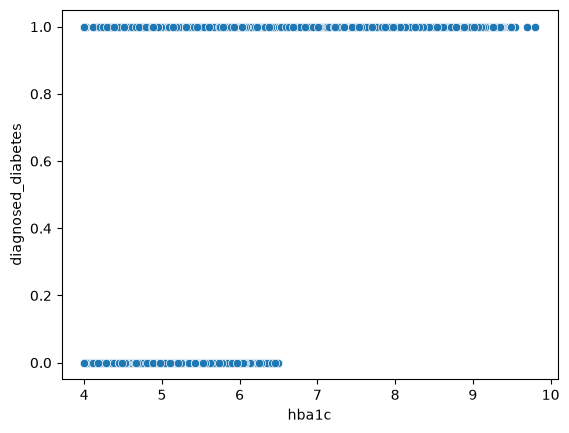

In [54]:
sns.scatterplot(
    data=df,
    x='hba1c',
    y='diagnosed_diabetes'
)

In [55]:
X = df.drop('diagnosed_diabetes', axis=1)
y = df['diagnosed_diabetes']
X.head()

,age,bmi,family_history_diabetes,hypertension_history,glucose_fasting,hba1c,physical_activity_minutes_per_week,cardiovascular_history,gender_Male,gender_Other,smoking_status_Former,smoking_status_Never
0,58,30.5,0,0,136,8.18,215,0,1,0,0,1
1,48,23.1,0,0,93,5.63,143,0,0,0,1,0
2,60,22.2,1,0,118,7.51,57,0,1,0,0,1
3,74,26.8,0,0,139,9.03,49,0,0,0,0,1
4,46,21.2,0,0,137,7.20,109,0,1,0,0,1


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [58]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-1.03453677,  0.72293205, -0.52975437, ..., -0.14221898,
        -0.50072647,  0.82016732],
       [-0.13685213, -0.31101723, -0.52975437, ..., -0.14221898,
        -0.50072647,  0.82016732],
       [ 0.76083251, -0.28307265, -0.52975437, ..., -0.14221898,
        -0.50072647, -1.21926341],
       ...,
       [-0.39333346, -0.1154052 , -0.52975437, ..., -0.14221898,
        -0.50072647,  0.82016732],
       [ 0.18374953,  0.6670429 , -0.52975437, ..., -0.14221898,
         1.99709835, -1.21926341],
       [-0.20097246, -0.3389618 , -0.52975437, ..., -0.14221898,
        -0.50072647, -1.21926341]], shape=(79999, 12))

In [59]:
from pathlib import Path

path = Path.cwd().parent.parent/'Ml_models and scalers'/'Scalers'/'diabetes_scaler.pkl'
path

WindowsPath('e:/ML Project/Ml_models and scalers/Scalers/diabetes_scaler.pkl')

In [60]:
import pickle

pickle.dump(scaler, open(path, 'wb'))

## Training the models and evaluation

- Logistic Regression
- KNeighborsClassifier
- DecisionTreeClassifier
- SVC

In [61]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, recall_score

In [62]:
## Logistic Regression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics\n{confusion_matrix(y_test, y_pred)}')
print(f'\nsccuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'f1_score : {f1_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')


Confusion Metrics
[[ 6444  1585]
 [ 1309 10662]]

sccuracy_score : 0.8553
f1_score : 0.8805021058716657
recall_score : 0.8906524099908111


In [63]:
# Using GridSearchCV

param_grid = {
    'C': [1,2,3,4,5],
    'fit_intercept': [True, False],
}

grid = GridSearchCV(LogisticRegression(), param_grid=param_grid, n_jobs=5, cv=5, )

grid.fit(X_train_scaled, y_train)
grid.best_params_

{'C': 5, 'fit_intercept': False}

In [64]:
model = LogisticRegression(C=5, fit_intercept=False)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics\n{confusion_matrix(y_test, y_pred)}')
print(f'\nsccuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'f1_score : {f1_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')

Confusion Metrics
[[7907  122]
 [2184 9787]]

sccuracy_score : 0.8847
f1_score : 0.8946069469835466
recall_score : 0.8175591011611394


In [65]:
model_path = Path.cwd().parent.parent/ 'ML_models and scalers' /'ML_Models'/'Diabetes'/'Logistic_model.pkl'
# model_path
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(model, file)

In [66]:
# KNeighborsClassifier

model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics\n{confusion_matrix(y_test, y_pred)}')
print(f'\nsccuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'f1_score : {f1_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')

Confusion Metrics
[[ 6972  1057]
 [ 1726 10245]]

sccuracy_score : 0.86085
f1_score : 0.8804193700855069
recall_score : 0.8558182273828419


In [67]:
# Using GridSearchCV
param_grid = {
    'n_neighbors':[3,5,7,9,11,13,15,17],
    'weights': ['uniform', 'distance'],
}

grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid=param_grid, cv=5, verbose=2)
grid.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   3.5s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.7s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.4s
[CV] END .....................n_neighbors=3, weights=uniform; total time=   2.8s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.7s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.3s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.2s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.2s
[CV] END ....................n_neighbors=3, weights=distance; total time=   2.1s
[CV] END .....................n_neighbors=5, weights=uniform; total time=   2.6s
[CV] END .....................n_neighbors=5, wei

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsCla...ier(n_jobs=-1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how 

In [68]:
grid.best_params_

{'n_neighbors': 17, 'weights': 'distance'}

In [69]:
model = KNeighborsClassifier(n_neighbors=17, weights='distance')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[ 7164   865]
 [ 1650 10321]]
accuracy score:0.87425
recall score: 0.8621669033497619
f1_score: 0.8913935311137021


In [70]:
model_path = Path.cwd().parent.parent/ 'ML_models and scalers' /'ML_Models'/'Diabetes'/'kNN_model.pkl'
# model_path
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(model, file)

In [71]:
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics\n{confusion_matrix(y_test, y_pred)}')
print(f'\nsccuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'f1_score : {f1_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')

Confusion Metrics
[[ 6475  1554]
 [ 1274 10697]]

sccuracy_score : 0.8586
f1_score : 0.8832466352902321
recall_score : 0.893576142343998


In [72]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [3,4,5,6,7,8],
    'min_samples_split': [4,6,8,10,15],
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid, cv=5, verbose=2)
grid.fit(X_train_scaled, y_train)
grid.best_params_

Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=best; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=random; total time=   0.0s
[CV] END criterion=gini, max_depth=3, min_samples_split=4, splitter=random; total time=   0.

{'criterion': 'gini',
 'max_depth': 3,
 'min_samples_split': 4,
 'splitter': 'best'}

In [73]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_split=4, splitter='best')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics\n{confusion_matrix(y_test, y_pred)}')
print(f'\nsccuracy_score : {accuracy_score(y_test, y_pred)}')
print(f'f1_score : {f1_score(y_test, y_pred)}')
print(f'recall_score : {recall_score(y_test, y_pred)}')

Confusion Metrics
[[ 8029     0]
 [ 1592 10379]]

sccuracy_score : 0.9204
f1_score : 0.9287695749440716
recall_score : 0.867011945535043


In [74]:
model_path = Path.cwd().parent.parent/ 'ML_models and scalers' /'ML_Models'/'Diabetes'/'tree_model.pkl'
# model_path
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(model, file)

In [75]:
# SVC

model = SVC(cache_size=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[ 7560   469]
 [ 1539 10432]]
accuracy score:0.8996
recall score: 0.8714393116698689
f1_score: 0.9122070654074851


In [76]:
model_path = Path.cwd().parent.parent/ 'ML_models and scalers' /'ML_Models'/'Diabetes'/'svc_model.pkl'
# model_path
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as file:
    pickle.dump(model, file)

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 2, 5],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],
}

grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5, verbose=2)
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:
df.sample(10)